# Chi Bubble Chart

Interactive notebook to inspect country-year sector bubbles using `chi`.
Bubble size uses sector `OUT` as a GDP proxy.


In [1]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz as viz
importlib.reload(viz)
prepare_country_bubble_data = viz.prepare_country_bubble_data
plot_country_bubble = viz.plot_country_bubble
import matplotlib.pyplot as plt

In [2]:
cfg = load_config('config/default.yaml')
country = 'USA'
year = 2019
metric = 'chi'


In [3]:
df = prepare_country_bubble_data(cfg=cfg, country=country, year=year, metric=metric)
label_top_n = len(df)
print(df[['label', 'sector_code', metric, 'out_proxy']].head(10).to_string(index=False))
print(f'rows={len(df)}  country={country}  year={year}  metric={metric}')

     label sector_code      chi   out_proxy
   USA_A01         A01 0.045663 436438.2818
   USA_A02         A02 0.024644  18411.6265
   USA_A03         A03 0.017272   5645.2839
   USA_B05         B05 0.050622  34441.0277
   USA_B07         B07 0.074496  26783.9430
   USA_B08         B08 0.052126  48271.0250
   USA_B09         B09 0.040117 107828.4893
USA_C10T12      C10T12 0.026605 959608.6917
USA_C13T15      C13T15 0.027314  67919.1895
   USA_C16         C16 0.028184 112456.1103
rows=48  country=USA  year=2019  metric=chi


<Figure size 2000x1000 with 0 Axes>

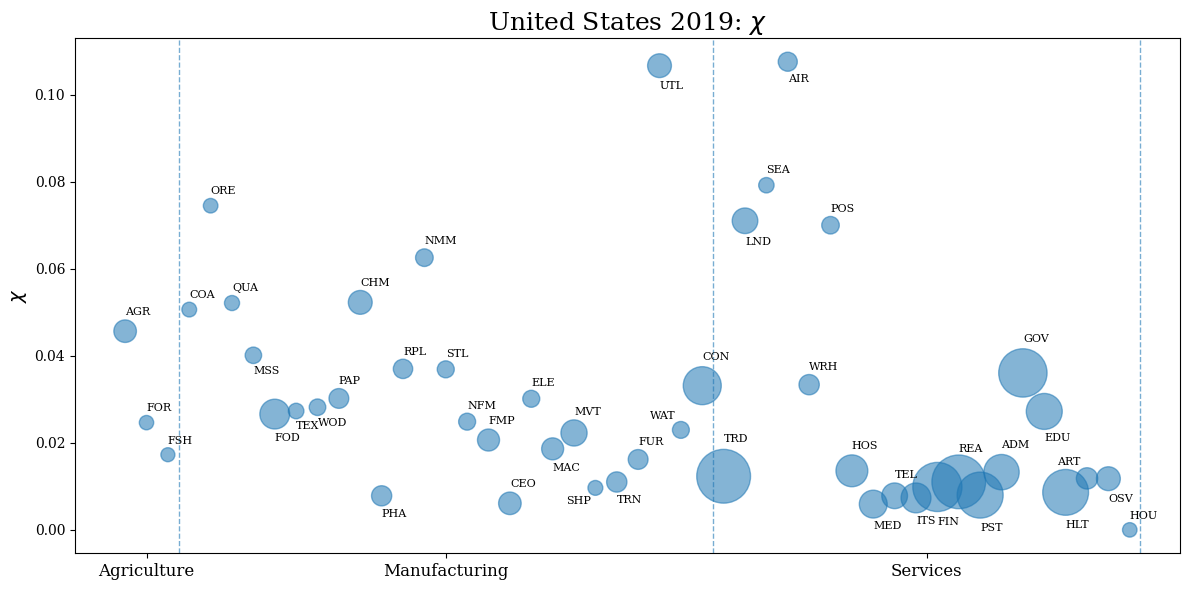

In [4]:
plt.figure(figsize=(20, 10))
metric_labels = {'chi': r'$\chi$'}
metric_label = metric_labels.get(metric, metric)
country_name = df['country_name'].dropna().iloc[0] if 'country_name' in df.columns and df['country_name'].notna().any() else country
title = f"{country_name} {year}: {metric_label}"
ax = plot_country_bubble(df, metric=metric, title=title, label_top_n=label_top_n)
plt.tight_layout()
plt.show()


## Try Different Inputs

- Change `country` (e.g., `USA`, `DEU`, `JPN`)
- Change `year` (1995-2022)
- `metric` is fixed to `chi` in this notebook
